<a href="https://colab.research.google.com/github/usmanumer038/ml-internship-work/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — Google Search Ranking & Discoverability

## Refresh / Content Opportunity Scoring

# A Grouped-Validation Content Opportunity Model for Human Review Prioritization

## Abstract

This capstone brings together the work completed from Week 1 to Week 7 in the Refresh / Content Opportunity Scoring lane. The final question is whether observed March 2026 search and engagement signals can help rank content items associated with a later decline in April sessions. The work uses a transparent Week-4 baseline, a Random Forest model, grouped-by-client validation, leakage checks, error analysis, and a practical human-review action playbook. On the measured grouped validation design, the Random Forest is compared directly with the Week-4 baseline on the same held-out client groups. The final output is a ranked review queue for decision-support; it does not prove why performance changes or that refreshing content will cause recovery.


## How the weekly notebooks connect

This capstone follows the actual progression of the internship work:

- **Week 1:** Choose the Refresh / Content Opportunity Scoring lane and define the business decision.
- **Week 2:** Frame the work as a classification and ranking problem and define how model quality should support a real decision.
- **Week 3:** Build the data contract, define the unit of analysis, document safe features, and test for leakage.
- **Week 4:** Build the transparent baseline action score using search visibility and low engagement.
- **Week 5:** Train a Random Forest and compare it directly with the Week-4 baseline.
- **Week 6:** Audit validation, compare random and grouped splits, check leakage, inspect failures, and rewrite claims safely.
- **Week 7:** Turn the validated output into a ranked content action playbook with reason codes, human review, limits, monitoring, and exports.

One early Week-2 framing used a provisional starter-data target about content trending up. As the lane moved to the full warehouse and the data contract was completed, the final capstone question was refined to the later-session-decline outcome used consistently in Weeks 4–7. This notebook uses that final, validated formulation.


## Setup

The FlyRank ML Internship warehouse is accessed through DuckDB and Hugging Face.

Public-safe rules:

- No client names.
- No domains or dataset URLs.
- No private queries.
- No credentials in notebook output.
- Only pseudonymized identifiers are used internally.
- The exported recommendation queue contains only pseudonymized IDs and derived decision-support fields.


In [1]:
!pip -q install duckdb scikit-learn pandas matplotlib

import os
import json
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import userdata
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, classification_report
from sklearn.inspection import permutation_importance

HF_TOKEN = userdata.get("HF_TOKEN")

con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{HF_TOKEN}')")

BASE = "hf://datasets/FlyRank/internship-warehouse"
TABLE = f"{BASE}/fact_content_daily_performance/**/*.parquet"

os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

print("Connected to FlyRank Internship Warehouse")


Connected to FlyRank Internship Warehouse


# 1. Question

## Research question

**Can observed March 2026 search and engagement signals help rank content items associated with a later decline in April sessions?**

## Decision supported

The practical decision comes from Week 1:

> **Which content items should a content team review first for refresh, expansion, updates, monitoring, or no action?**

The model does not decide that content is stale. It prioritizes which items a human should inspect first.

## Intended workflow

**Observed signals → ranked priority → human review → evidence check → possible action → later monitoring**

This keeps the model in a decision-support role.


In [2]:
research_question = (
    "Can observed March 2026 search and engagement signals help rank content "
    "items associated with a later decline in April sessions?"
)

decision_supported = (
    "Prioritize content items for human review before any refresh, rewrite, "
    "expansion, monitoring, or other content action."
)

print("Research question:")
print(research_question)
print("\nDecision supported:")
print(decision_supported)


Research question:
Can observed March 2026 search and engagement signals help rank content items associated with a later decline in April sessions?

Decision supported:
Prioritize content items for human review before any refresh, rewrite, expansion, monitoring, or other content action.


# 2. Data

## Data contract carried from Week 3

**Primary table:** `fact_content_daily_performance`

**Development feature window:** March 2026

**Future outcome window:** April 2026

**Final unit used for modeling:** one row per pseudonymized client and pseudonymized content item after monthly aggregation.

The model uses March signals that are available before the April outcome.

## Final feature set

The final Week-5 to Week-7 feature set is:

- impressions,
- clicks,
- sessions,
- engaged sessions,
- engagement rate.

Engagement rate is calculated from March data:

**engaged sessions / sessions**

## Exclusions

- Client and content hash IDs are used only for grouping or identification, not as predictive features.
- April sessions are excluded from the feature matrix because they are future information.
- The target itself is excluded from features.
- No product flags or label-derived features are used.


**Final consistency rule:** the capstone uses one March-to-April modeling population throughout. March content is retained with a `LEFT JOIN` to April outcomes, and missing April sessions are treated as `0` with `COALESCE`. This matches the final Week-7 validation logic.

In [3]:
# Final modeling dataset used consistently across the capstone.
# March provides features. April provides the future outcome.
# IMPORTANT: This matches the Week-7 validation logic.
# A LEFT JOIN keeps March content items even when no April row exists.
# Missing April sessions are treated as 0 for the defined future outcome.

model_query = f'''
WITH march AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions
    FROM read_parquet('{TABLE}', hive_partitioning=1)
    WHERE month = '2026-03'
      AND gsc_data_available IS TRUE
      AND ga4_data_available IS TRUE
      AND ga4_sessions > 0
    GROUP BY 1, 2
),
april AS (
    SELECT
        client_hash_id,
        content_hash_id,
        SUM(ga4_sessions) AS april_sessions
    FROM read_parquet('{TABLE}', hive_partitioning=1)
    WHERE month = '2026-04'
      AND ga4_data_available IS TRUE
    GROUP BY 1, 2
)
SELECT
    m.client_hash_id,
    m.content_hash_id,
    m.impressions,
    m.clicks,
    m.sessions,
    m.engaged_sessions,
    COALESCE(a.april_sessions, 0) AS april_sessions
FROM march m
LEFT JOIN april a
    ON m.client_hash_id = a.client_hash_id
   AND m.content_hash_id = a.content_hash_id
'''

df = con.sql(model_query).df()

df["engagement_rate"] = (
    df["engaged_sessions"] / df["sessions"]
).clip(0, 1)

# 1 = April sessions lower than March sessions
# 0 = April sessions equal to or higher than March sessions
df["target_decline"] = (
    df["april_sessions"] < df["sessions"]
).astype(int)

data_summary = {
    "rows": int(len(df)),
    "unique_clients": int(df["client_hash_id"].nunique()),
    "unique_content_items": int(df["content_hash_id"].nunique()),
    "target_positive_rate": round(float(df["target_decline"].mean()), 4)
}

print(json.dumps(data_summary, indent=2))
display(df.head())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

{
  "rows": 63650,
  "unique_clients": 34,
  "unique_content_items": 63650,
  "target_positive_rate": 0.5239
}


,client_hash_id,content_hash_id,impressions,clicks,sessions,engaged_sessions,april_sessions,engagement_rate,target_decline
0,client_65de48885f4ef01b,content_b1f61fc81b28b2d4,458.0,2.0,14.0,0.0,13.0,0.000000,1
1,client_65de48885f4ef01b,content_e25ea7297a1dffd3,3943.0,23.0,54.0,1.0,49.0,0.018519,1
2,client_65de48885f4ef01b,content_3c286ded8bd68120,2180.0,15.0,30.0,2.0,16.0,0.066667,1
3,client_65de48885f4ef01b,content_b2108e8fe3360fa6,503.0,8.0,23.0,1.0,19.0,0.043478,1
4,client_65de48885f4ef01b,content_ff867882e604fa96,24.0,0.0,2.0,0.0,10.0,0.000000,0


# 3. Methodology

## From Week 1: the business problem

The project started with a content-review backlog problem: a team cannot manually inspect every content item with the same effort. A ranked queue helps focus limited review capacity.

A false positive can waste human review time. A false negative can cause a potentially declining item to receive no review.

## From Week 2: ML task framing

The final task is a binary classification problem used for ranking:

- **Positive class (1):** April sessions are lower than March sessions.
- **Negative class (0):** April sessions are equal to or higher than March sessions.

ROC-AUC is used because the output is a ranking score and the comparison asks whether one method ranks later-declining items above non-declining items.

## From Week 3: leakage discipline

Only March information is available to the model. April sessions are used only after the March feature window to create the outcome.

## From Week 4: baseline

The baseline is a transparent action score:

**Baseline score = 0.6 × normalized impressions + 0.4 × inverse engagement rate**

Reason code:

`HIGH_VISIBILITY_LOW_ENGAGEMENT`

Action:

`REVIEW_FOR_REFRESH`

## From Week 5: model choice

A Random Forest is used because the observed signals may interact in non-linear ways and the output can be used as a ranking probability. The model is not rewarded for complexity alone; it must beat the Week-4 baseline on the same held-out grouped split.

## From Week 6: honest validation

The preferred validation design groups by pseudonymized client. A client cannot appear in both training and testing.


In [4]:
features = [
    "impressions",
    "clicks",
    "sessions",
    "engaged_sessions",
    "engagement_rate"
]

X = df[features].copy()
y = df["target_decline"].copy()
groups = df["client_hash_id"].copy()

# Grouped split from Weeks 5 and 6.
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

train_clients = set(groups.iloc[train_idx])
test_clients = set(groups.iloc[test_idx])
client_overlap = len(train_clients.intersection(test_clients))

assert client_overlap == 0

print("Train rows:", len(X_train))
print("Test rows:", len(X_test))
print("Train clients:", len(train_clients))
print("Test clients:", len(test_clients))
print("Client overlap:", client_overlap)
print("Train positive rate:", round(float(y_train.mean()), 3))
print("Test positive rate:", round(float(y_test.mean()), 3))


Train rows: 51222
Test rows: 12428
Train clients: 25
Test clients: 9
Client overlap: 0
Train positive rate: 0.478
Test positive rate: 0.712


## Leakage audit

A feature is risky if it contains:

- future information,
- the future outcome,
- a transformation of the future outcome, or
- information unavailable at the March decision moment.

The final feature set is checked below.


In [5]:
leakage_audit = pd.DataFrame({
    "Column": [
        "impressions",
        "clicks",
        "sessions",
        "engaged_sessions",
        "engagement_rate",
        "april_sessions",
        "target_decline"
    ],
    "Available at March prediction time": [
        "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"
    ],
    "Used as model feature": [
        "Yes", "Yes", "Yes", "Yes", "Yes", "No", "No"
    ],
    "Assessment": [
        "Observed March signal",
        "Observed March signal",
        "Observed March signal",
        "Observed March signal",
        "Derived only from March signals",
        "Future outcome information: excluded",
        "Target itself: excluded"
    ]
})

assert "april_sessions" not in features
assert "target_decline" not in features

display(leakage_audit)
print("Leakage check passed.")


,Column,Available at March prediction time,Used as model feature,Assessment
0,impressions,Yes,Yes,Observed March signal
1,clicks,Yes,Yes,Observed March signal
2,sessions,Yes,Yes,Observed March signal
3,engaged_sessions,Yes,Yes,Observed March signal
4,engagement_rate,Yes,Yes,Derived only from March signals
5,april_sessions,No,No,Future outcome information: excluded
6,target_decline,No,No,Target itself: excluded


Leakage check passed.


# 4. Results (vs baseline)

This section uses the exact Week-4 baseline logic and compares it with the Week-5 Random Forest on the **same grouped-by-client test split**.

This is the main comparison of the capstone.

A higher ROC-AUC means the method measured better ranking discrimination between items with and without a later decline on this held-out grouped test set. It does not prove causation.


**Consistency note:** the baseline, Random Forest, and grouped validation in this section all use the same March-to-April dataset definition.

In [6]:
# Week-4 baseline recreated using March signals only.
# Normalization uses training data so test information does not influence the score scale.

test_data = df.iloc[test_idx].copy()

max_train_impressions = X_train["impressions"].max()

test_data["visibility_score"] = (
    test_data["impressions"] / max_train_impressions
).clip(0, 1)

test_data["low_engagement_score"] = (
    1 - test_data["engagement_rate"]
).clip(0, 1)

test_data["baseline_score"] = (
    0.6 * test_data["visibility_score"] +
    0.4 * test_data["low_engagement_score"]
)

baseline_auc = roc_auc_score(
    y_test,
    test_data["baseline_score"]
)

print("Week-4 baseline ROC-AUC:", round(float(baseline_auc), 4))


Week-4 baseline ROC-AUC: 0.5396


In [7]:
# Week-5 Random Forest configuration.

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

model_prob = model.predict_proba(X_test)[:, 1]
model_auc = roc_auc_score(y_test, model_prob)

comparison = pd.DataFrame({
    "Method": [
        "Week-4 baseline action score",
        "Week-5 Random Forest model"
    ],
    "Validation design": [
        "Grouped by client",
        "Grouped by client"
    ],
    "ROC-AUC": [
        baseline_auc,
        model_auc
    ]
})

comparison["ROC-AUC"] = comparison["ROC-AUC"].round(4)
comparison["Difference vs baseline"] = [
    0.0,
    round(float(model_auc - baseline_auc), 4)
]

display(comparison)

print("Client overlap:", client_overlap)


,Method,Validation design,ROC-AUC,Difference vs baseline
0,Week-4 baseline action score,Grouped by client,0.5396,0.0000
1,Week-5 Random Forest model,Grouped by client,0.7932,0.2537


Client overlap: 0


In [8]:
winner = comparison.loc[
    comparison["ROC-AUC"].idxmax(),
    "Method"
]

difference = abs(float(model_auc - baseline_auc))

print("Better method on this split:", winner)
print("Absolute ROC-AUC difference:", round(difference, 4))

if model_auc > baseline_auc:
    print(
        "Observation: the Random Forest improved measured ranking performance "
        "over the Week-4 baseline on this held-out grouped split."
    )
else:
    print(
        "Observation: the Week-4 baseline matched or outperformed the model. "
        "Extra complexity was not rewarded."
    )


Better method on this split: Week-5 Random Forest model
Absolute ROC-AUC difference: 0.2537
Observation: the Random Forest improved measured ranking performance over the Week-4 baseline on this held-out grouped split.


## Week 6 validation audit: before and after

Week 6 compared:

- **Before:** random row split.
- **After:** grouped-by-client split.

The grouped design is preferred because it prevents the same client's patterns from appearing in both training and test data.

The score is not required to be lower under grouped validation. The important honesty check is that client overlap is zero.


Both validation numbers are calculated from the same final modeling population. Only the split design changes.

In [9]:
# Before: random row split

Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

random_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

random_model.fit(Xtr_r, ytr_r)

random_auc = roc_auc_score(
    yte_r,
    random_model.predict_proba(Xte_r)[:, 1]
)

# After: grouped result is model_auc from the main split.
grouped_auc = model_auc

validation_comparison = pd.DataFrame({
    "Validation design": [
        "Random row split (before)",
        "Grouped by client (after)"
    ],
    "ROC-AUC": [
        random_auc,
        grouped_auc
    ]
})

validation_comparison["ROC-AUC"] = (
    validation_comparison["ROC-AUC"].round(4)
)

display(validation_comparison)

print(
    "Difference (random - grouped):",
    round(float(random_auc - grouped_auc), 4)
)
print("Client overlap:", client_overlap)


,Validation design,ROC-AUC
0,Random row split (before),0.7873
1,Grouped by client (after),0.7932


Difference (random - grouped): -0.0059
Client overlap: 0


## Errors and interpretation

The model can be wrong because observed March signals do not capture every factor that changes in April.

This section inspects:

- **False positives:** the model predicted decline, but April sessions did not decline.
- **False negatives:** April sessions declined, but the model did not predict decline.

Both error types matter because the output is a human review queue.


In [10]:
error_df = df.iloc[test_idx].copy()
error_df["predicted_probability"] = model_prob
error_df["predicted_decline"] = (
    error_df["predicted_probability"] >= 0.5
).astype(int)

false_positives = error_df[
    (error_df["predicted_decline"] == 1) &
    (error_df["target_decline"] == 0)
]

false_negatives = error_df[
    (error_df["predicted_decline"] == 0) &
    (error_df["target_decline"] == 1)
]

print("False positives:", len(false_positives))
print("False negatives:", len(false_negatives))

print("\nExample false positives:")
display(
    false_positives[
        features + [
            "april_sessions",
            "target_decline",
            "predicted_probability"
        ]
    ].head(5)
)

print("\nExample false negatives:")
display(
    false_negatives[
        features + [
            "april_sessions",
            "target_decline",
            "predicted_probability"
        ]
    ].head(5)
)


False positives: 519
False negatives: 3629

Example false positives:


,impressions,clicks,sessions,engaged_sessions,engagement_rate,april_sessions,target_decline,predicted_probability
13,227.0,7.0,12.0,1.0,0.083333,13.0,0,0.535486
267,399.0,9.0,21.0,3.0,0.142857,21.0,0,0.655451
270,22.0,2.0,6.0,0.0,0.000000,12.0,0,0.613854
298,9.0,0.0,3.0,0.0,0.000000,3.0,0,0.595444
311,47.0,6.0,5.0,0.0,0.000000,8.0,0,0.539190



Example false negatives:


,impressions,clicks,sessions,engaged_sessions,engagement_rate,april_sessions,target_decline,predicted_probability
259,84.0,3.0,3.0,0.0,0.0,1.0,1,0.424394
262,441.0,3.0,9.0,0.0,0.0,6.0,1,0.409990
263,3170.0,10.0,16.0,0.0,0.0,6.0,1,0.356461
265,33.0,0.0,3.0,0.0,0.0,2.0,1,0.489364
269,1124.0,9.0,12.0,0.0,0.0,4.0,1,0.329804


In [11]:
importance = permutation_importance(
    model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "feature": features,
    "importance_mean": importance.importances_mean
}).sort_values(
    "importance_mean",
    ascending=False
)

importance_df["importance_mean"] = (
    importance_df["importance_mean"].round(4)
)

display(importance_df)


,feature,importance_mean
2,sessions,0.3305
0,impressions,0.0315
1,clicks,0.0296
3,engaged_sessions,0.0152
4,engagement_rate,0.0074


### Interpretation

Permutation importance shows how much measured ROC-AUC changes when one feature is shuffled. It is an interpretation tool, not proof of causation.

The model may be wrong because of factors not represented in the selected March signals, including:

- external traffic changes,
- changing search intent,
- client-level differences,
- limited history in the feature set.

The result remains directional decision-support for human review.


# 5. Limitations

## What this work cannot claim

- It does not prove why sessions decline.
- It does not prove that a content item is outdated.
- It does not prove that low engagement is caused by poor content.
- It does not prove that refreshing content will improve performance.
- It does not prove anything about Google's ranking algorithm.
- It does not establish a causal relationship between the input signals and future decline.
- It does not guarantee identical performance for every client or future period.

## Validation limits

The grouped split prevents client overlap, but target rates can still differ between client groups. The measured ROC-AUC is therefore interpreted as a directional result for this historical validation design.

## Claim rewrite from Week 6

Unsafe:

> "The Random Forest model predicts which content will decline and should be refreshed."

Safer:

> "On the held-out grouped-by-client split, the Random Forest measured the ROC-AUC reported in this notebook for ranking content items associated with a later decline in sessions."

The safer version does not claim that refresh actions cause recovery.


In [12]:
limitations_check = {
    "causation_not_claimed": True,
    "automatic_refresh_not_claimed": True,
    "google_algorithm_claim_not_made": True,
    "human_review_required": True,
    "grouped_validation_used": True,
    "future_outcome_excluded_from_features": True
}

print(json.dumps(limitations_check, indent=2))


{
  "causation_not_claimed": true,
  "automatic_refresh_not_claimed": true,
  "google_algorithm_claim_not_made": true,
  "human_review_required": true,
  "grouped_validation_used": true,
  "future_outcome_excluded_from_features": true
}


# 6. Ranked recommendations

This section carries forward the Week-7 Content Action Playbook.

After the grouped validation result is measured, the same validated Random Forest configuration is fitted on all available labeled rows. It then scores the March content population.

The score determines review priority, not an automatic content change.

## Action levels

- **High priority review:** model score ≥ 0.70.
- **Standard review:** model score ≥ 0.50 and < 0.70.
- **Monitor:** model score < 0.50.

## Reason codes

Reason codes summarize observed March patterns:

- High search visibility.
- Low engagement rate.
- High current traffic.
- Model score indicates review priority.

These are explanations for prioritization, not causal explanations.


**Consistency note:** the model fitted for the action playbook uses the same dataset definition as the final validation. The queue itself is generated from March-only prediction-time features.

In [13]:
# Week-7 queue population: March data only.

march_queue_query = f'''
SELECT
    client_hash_id,
    content_hash_id,
    SUM(gsc_impressions) AS impressions,
    SUM(gsc_clicks) AS clicks,
    SUM(ga4_sessions) AS sessions,
    SUM(ga4_engaged_sessions) AS engaged_sessions
FROM read_parquet('{TABLE}', hive_partitioning=1)
WHERE month = '2026-03'
  AND gsc_data_available IS TRUE
  AND ga4_data_available IS TRUE
  AND ga4_sessions > 0
GROUP BY 1, 2
'''

queue_df = con.sql(march_queue_query).df()

queue_df["engagement_rate"] = (
    queue_df["engaged_sessions"] / queue_df["sessions"]
).clip(0, 1)

print("March content items available for queue:", len(queue_df))


March content items available for queue: 63650


In [14]:
# Consistency check for the final capstone.
# Do not create a second validation dataset here.
# The main dataset `df` is the single source of truth for:
# - grouped validation
# - Week-4 baseline comparison
# - Random Forest evaluation
# - random-vs-grouped comparison
# - error analysis
# - permutation importance
# - final model fitting for the Week-7-style action playbook

assert client_overlap == 0

consistency_check = {
    "dataset_definition": (
        "March features + LEFT JOIN April outcomes + "
        "COALESCE(missing April sessions to 0)"
    ),
    "modeling_rows": int(len(df)),
    "target_positive_rate": round(float(y.mean()), 4),
    "grouped_validation_roc_auc": round(float(model_auc), 4),
    "client_overlap": int(client_overlap),
    "single_dataset_used_for_final_validation": True
}

print(json.dumps(consistency_check, indent=2))
print(
    "\nConsistency check passed: the capstone uses one modeling population "
    "for evaluation and the final action-playbook model."
)


{
  "dataset_definition": "March features + LEFT JOIN April outcomes + COALESCE(missing April sessions to 0)",
  "modeling_rows": 63650,
  "target_positive_rate": 0.5239,
  "grouped_validation_roc_auc": 0.7932,
  "client_overlap": 0,
  "single_dataset_used_for_final_validation": true
}

Consistency check passed: the capstone uses one modeling population for evaluation and the final action-playbook model.


In [15]:
# Fit the validated Week-7 configuration on all available labeled rows
# from the SAME dataset used for the capstone validation.

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

final_model.fit(X, y)

queue_df["model_score"] = (
    final_model.predict_proba(queue_df[features])[:, 1]
)

# Week-7 observed reason-code thresholds.
impression_threshold = queue_df["impressions"].quantile(0.75)
low_engagement_threshold = queue_df["engagement_rate"].quantile(0.25)
session_threshold = queue_df["sessions"].quantile(0.75)

def build_reason(row):
    reasons = []

    if row["impressions"] >= impression_threshold:
        reasons.append("High search visibility")

    if row["engagement_rate"] <= low_engagement_threshold:
        reasons.append("Low engagement rate")

    if row["sessions"] >= session_threshold:
        reasons.append("High current traffic")

    if not reasons:
        reasons.append("Model score indicates review priority")

    return "; ".join(reasons[:2])

queue_df["reason_code"] = queue_df.apply(build_reason, axis=1)

def choose_action(score):
    if score >= 0.70:
        return "High priority review"
    elif score >= 0.50:
        return "Standard review"
    return "Monitor"

queue_df["recommended_action"] = queue_df["model_score"].apply(choose_action)

ranked_queue = queue_df.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

ranked_queue["rank"] = ranked_queue.index + 1

# Public notebook display: show aggregate-safe columns only.
display(
    ranked_queue[
        [
            "rank",
            "model_score",
            "recommended_action",
            "reason_code"
        ]
    ].head(20)
)


,rank,model_score,recommended_action,reason_code
0,1,0.980693,High priority review,High search visibility; High current traffic
1,2,0.980514,High priority review,High search visibility; High current traffic
2,3,0.980164,High priority review,High search visibility; High current traffic
3,4,0.979686,High priority review,High search visibility; High current traffic
4,5,0.979668,High priority review,High search visibility; High current traffic
5,6,0.979607,High priority review,High search visibility; High current traffic
6,7,0.979571,High priority review,High search visibility; High current traffic
7,8,0.979414,High priority review,High search visibility; High current traffic
8,9,0.979412,High priority review,High search visibility; High current traffic
9,10,0.979403,High priority review,High search visibility; High current traffic


## Archetype → action mapping

The Week-7 playbook adds an observed-signal archetype to help a reviewer understand what to inspect.

| Archetype | Suggested human action |
|---|---|
| High visibility, low engagement | Review search intent, relevance, structure, and usefulness |
| High traffic, high risk score | Prioritize human review because more observed traffic may be affected |
| High model score, mixed signals | Inspect manually before selecting any content action |
| Lower model score | Monitor; no immediate content change recommended |

The archetype is a review aid. It is not a diagnosis of the cause of decline.


In [16]:
def assign_archetype(row):
    if (
        row["impressions"] >= impression_threshold and
        row["engagement_rate"] <= low_engagement_threshold
    ):
        return "High visibility, low engagement"

    if (
        row["sessions"] >= session_threshold and
        row["model_score"] >= 0.70
    ):
        return "High traffic, high risk score"

    if row["model_score"] >= 0.50:
        return "High model score, mixed signals"

    return "Lower model score"

ranked_queue["archetype"] = ranked_queue.apply(
    assign_archetype,
    axis=1
)

archetype_actions = {
    "High visibility, low engagement":
        "Review search intent, relevance, structure, and usefulness",
    "High traffic, high risk score":
        "Prioritize human review because more observed traffic may be affected",
    "High model score, mixed signals":
        "Inspect manually before selecting any content action",
    "Lower model score":
        "Monitor; no immediate content change recommended"
}

ranked_queue["human_review_action"] = (
    ranked_queue["archetype"].map(archetype_actions)
)

# Week-7 cost/value support.
max_sessions = ranked_queue["sessions"].max()

ranked_queue["traffic_weight"] = (
    ranked_queue["sessions"] / max_sessions
).clip(0, 1)

ranked_queue["review_priority_value"] = (
    0.7 * ranked_queue["model_score"] +
    0.3 * ranked_queue["traffic_weight"]
).round(4)

display(
    ranked_queue[
        [
            "rank",
            "archetype",
            "recommended_action",
            "reason_code",
            "human_review_action",
            "model_score",
            "review_priority_value"
        ]
    ].head(20)
)


,rank,archetype,recommended_action,reason_code,human_review_action,model_score,review_priority_value
0,1,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980693,0.7143
1,2,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980514,0.7099
2,3,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.980164,0.7010
3,4,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979686,0.7379
4,5,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979668,0.7071
5,6,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979607,0.7150
6,7,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979571,0.6972
7,8,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979414,0.7038
8,9,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979412,0.7265
9,10,"High traffic, high risk score",High priority review,High search visibility; High current traffic,Prioritize human review because more observed ...,0.979403,0.6987


## Human review and no-go list

Before changing content, a reviewer should check:

1. Current relevance and search intent.
2. Freshness and completeness.
3. Recent performance context.
4. SEO, editorial, brand, legal, and user-experience risks.
5. Whether expected value justifies the human effort.

### What should not be automated

The model should not automatically:

- publish refreshed content,
- rewrite or delete content,
- change URLs,
- change important SEO metadata without review,
- redirect pages,
- decide that content is obsolete,
- claim that a refresh will recover traffic.

Safe workflow:

**Model ranking → human review → evidence check → possible action → later monitoring**


## Monitoring and retrain triggers

The Week-7 playbook treats the model as something to monitor rather than something permanently valid.

Review or revalidate when:

- required data availability changes,
- feature distributions shift materially,
- the decline rate changes substantially,
- measured grouped validation performance drops,
- the content population changes,
- false positives or false negatives create too much review cost,
- a workflow change affects how the data should be interpreted.

These are monitoring and review triggers, not automatic retraining rules.


# 7. Charts and artifacts for the research paper

The following files are generated for the deployed paper:

1. Model vs Week-4 baseline chart.
2. Random vs grouped validation chart.
3. Ranked action queue distribution.
4. Feature importance chart.
5. Public-safe ranked recommendation queue.
6. Capstone metrics JSON.
7. Monitoring baseline JSON.


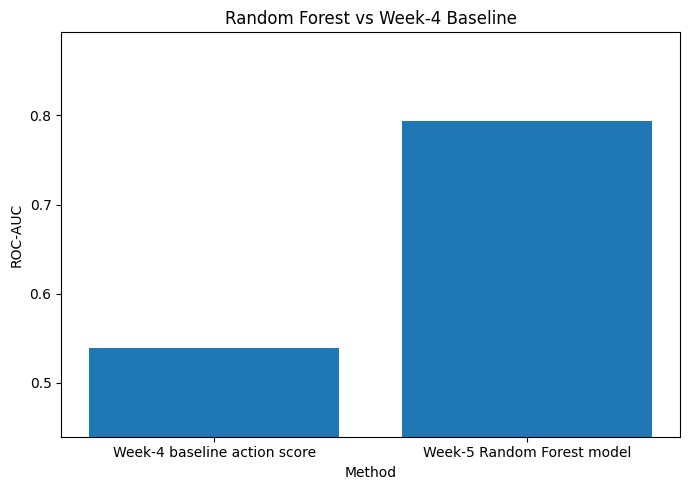

Saved: work/figures/capstone_model_vs_week4_baseline.png


In [17]:
# Figure 1: model vs actual Week-4 baseline

plt.figure(figsize=(7, 5))
plt.bar(comparison["Method"], comparison["ROC-AUC"])
plt.title("Random Forest vs Week-4 Baseline")
plt.xlabel("Method")
plt.ylabel("ROC-AUC")
plt.ylim(
    max(0, comparison["ROC-AUC"].min() - 0.1),
    min(1, comparison["ROC-AUC"].max() + 0.1)
)
plt.xticks(rotation=0)
plt.tight_layout()

path_model = "work/figures/capstone_model_vs_week4_baseline.png"
plt.savefig(path_model, dpi=150)
plt.show()

print("Saved:", path_model)


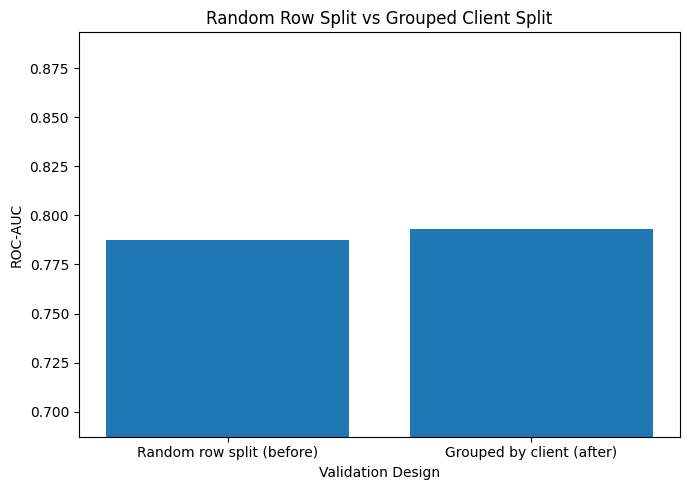

Saved: work/figures/capstone_validation_design.png


In [18]:
# Figure 2: validation design comparison

plt.figure(figsize=(7, 5))
plt.bar(
    validation_comparison["Validation design"],
    validation_comparison["ROC-AUC"]
)
plt.title("Random Row Split vs Grouped Client Split")
plt.xlabel("Validation Design")
plt.ylabel("ROC-AUC")
plt.ylim(
    max(0, validation_comparison["ROC-AUC"].min() - 0.1),
    min(1, validation_comparison["ROC-AUC"].max() + 0.1)
)
plt.xticks(rotation=0)
plt.tight_layout()

path_validation = "work/figures/capstone_validation_design.png"
plt.savefig(path_validation, dpi=150)
plt.show()

print("Saved:", path_validation)


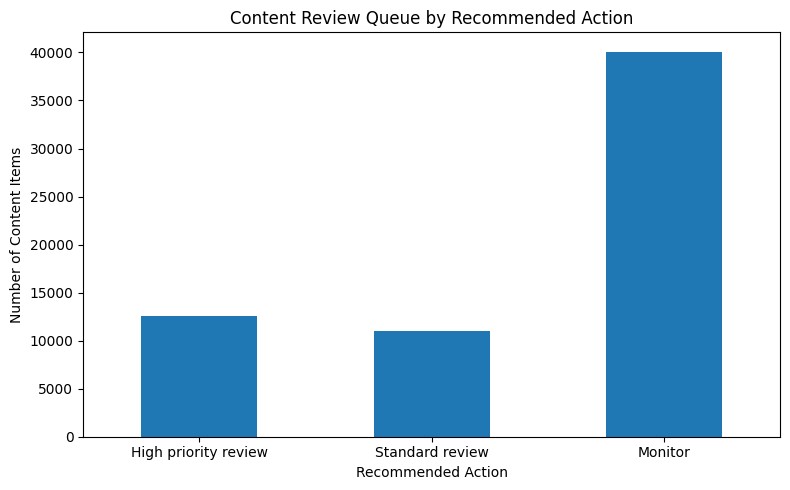

Saved: work/figures/capstone_action_queue_distribution.png


In [19]:
# Figure 3: action queue distribution

action_plot = (
    ranked_queue["recommended_action"]
    .value_counts()
    .reindex(
        ["High priority review", "Standard review", "Monitor"],
        fill_value=0
    )
)

plt.figure(figsize=(8, 5))
action_plot.plot(kind="bar")
plt.title("Content Review Queue by Recommended Action")
plt.xlabel("Recommended Action")
plt.ylabel("Number of Content Items")
plt.xticks(rotation=0)
plt.tight_layout()

path_queue = "work/figures/capstone_action_queue_distribution.png"
plt.savefig(path_queue, dpi=150)
plt.show()

print("Saved:", path_queue)


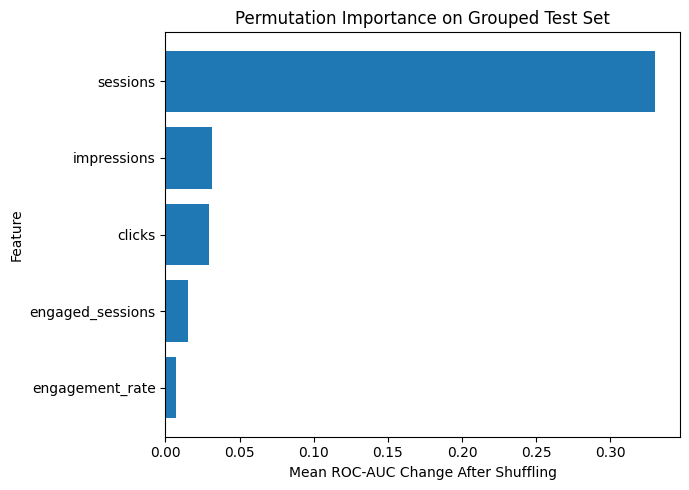

Saved: work/figures/capstone_feature_importance.png


In [20]:
# Figure 4: permutation importance

importance_plot = importance_df.sort_values(
    "importance_mean",
    ascending=True
)

plt.figure(figsize=(7, 5))
plt.barh(
    importance_plot["feature"],
    importance_plot["importance_mean"]
)
plt.title("Permutation Importance on Grouped Test Set")
plt.xlabel("Mean ROC-AUC Change After Shuffling")
plt.ylabel("Feature")
plt.tight_layout()

path_importance = "work/figures/capstone_feature_importance.png"
plt.savefig(path_importance, dpi=150)
plt.show()

print("Saved:", path_importance)


In [21]:
# Ranked queue export for local/regenerated workflow use.
# Do not commit this CSV to a public repository and do not embed content IDs
# in the deployed research paper. The public paper should use aggregate counts
# and charts instead.

export_columns = [
    "rank",
    "content_hash_id",
    "model_score",
    "recommended_action",
    "reason_code",
    "archetype",
    "human_review_action",
    "review_priority_value"
]

export_queue = ranked_queue[export_columns].copy()
export_queue["model_score"] = export_queue["model_score"].round(4)

queue_export_path = "work/outputs/capstone_ranked_content_queue.csv"

export_queue.to_csv(queue_export_path, index=False)

print("Saved local/regenerated queue:", queue_export_path)
print("Rows exported:", len(export_queue))
print(
    "Public-safety note: do not commit this raw queue CSV or display "
    "content_hash_id values in the deployed paper."
)

# Show only aggregate action counts in the notebook output.
display(
    export_queue["recommended_action"]
    .value_counts()
    .rename_axis("recommended_action")
    .reset_index(name="items")
)


Saved local/regenerated queue: work/outputs/capstone_ranked_content_queue.csv
Rows exported: 63650
Public-safety note: do not commit this raw queue CSV or display content_hash_id values in the deployed paper.


,recommended_action,items
0,Monitor,40088
1,High priority review,12564
2,Standard review,10998


In [22]:
# Compact metrics receipt for the deployed paper.
# All final evaluation metrics below come from the SAME modeling dataset `df`.

action_counts = export_queue["recommended_action"].value_counts()

capstone_metrics = {
    "lane": "Refresh / Content Opportunity Scoring",
    "baseline_name": "Week-4 baseline action score",
    "baseline_formula": (
        "0.6 * normalized impressions + "
        "0.4 * inverse engagement rate"
    ),
    "dataset_definition": (
        "March features + LEFT JOIN April outcomes + "
        "COALESCE missing April sessions to 0"
    ),
    "baseline_grouped_roc_auc": round(float(baseline_auc), 4),
    "random_forest_grouped_roc_auc": round(float(model_auc), 4),
    "random_row_split_roc_auc": round(float(random_auc), 4),
    "grouped_client_overlap": int(client_overlap),
    "modeling_target_positive_rate": round(float(y.mean()), 4),
    "queue_items": int(len(export_queue)),
    "high_priority_items": int(
        action_counts.get("High priority review", 0)
    ),
    "standard_review_items": int(
        action_counts.get("Standard review", 0)
    ),
    "monitor_items": int(
        action_counts.get("Monitor", 0)
    )
}

metrics_path = "work/outputs/capstone_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(capstone_metrics, f, indent=2)

print(json.dumps(capstone_metrics, indent=2))
print("Saved:", metrics_path)


{
  "lane": "Refresh / Content Opportunity Scoring",
  "baseline_name": "Week-4 baseline action score",
  "baseline_formula": "0.6 * normalized impressions + 0.4 * inverse engagement rate",
  "dataset_definition": "March features + LEFT JOIN April outcomes + COALESCE missing April sessions to 0",
  "baseline_grouped_roc_auc": 0.5396,
  "random_forest_grouped_roc_auc": 0.7932,
  "random_row_split_roc_auc": 0.7873,
  "grouped_client_overlap": 0,
  "modeling_target_positive_rate": 0.5239,
  "queue_items": 63650,
  "high_priority_items": 12564,
  "standard_review_items": 10998,
  "monitor_items": 40088
}
Saved: work/outputs/capstone_metrics.json


In [23]:
# Monitoring baseline receipt.
# Uses the same final validation population and action queue.

monitoring_baseline = {
    "model_version": "random_forest_week7_playbook",
    "dataset_definition": (
        "March features + LEFT JOIN April outcomes + "
        "COALESCE missing April sessions to 0"
    ),
    "grouped_validation_roc_auc": round(float(model_auc), 4),
    "grouped_client_overlap": int(client_overlap),
    "rows_ranked": int(len(ranked_queue)),
    "target_positive_rate": round(float(y.mean()), 4),
    "median_impressions": round(
        float(ranked_queue["impressions"].median()), 4
    ),
    "median_sessions": round(
        float(ranked_queue["sessions"].median()), 4
    ),
    "median_engagement_rate": round(
        float(ranked_queue["engagement_rate"].median()), 4
    )
}

monitoring_path = "work/outputs/capstone_monitoring_baseline.json"

with open(monitoring_path, "w", encoding="utf-8") as f:
    json.dump(monitoring_baseline, f, indent=2)

print(json.dumps(monitoring_baseline, indent=2))
print("Saved:", monitoring_path)


{
  "model_version": "random_forest_week7_playbook",
  "dataset_definition": "March features + LEFT JOIN April outcomes + COALESCE missing April sessions to 0",
  "grouped_validation_roc_auc": 0.7932,
  "grouped_client_overlap": 0,
  "rows_ranked": 63650,
  "target_positive_rate": 0.5239,
  "median_impressions": 106.0,
  "median_sessions": 4.0,
  "median_engagement_rate": 0.0
}
Saved: work/outputs/capstone_monitoring_baseline.json


# Reproducibility

This capstone is the final summary of the weekly notebook progression.

Recommended repository files:

- `work/notebooks/w01_research_question.ipynb`
- `work/notebooks/w02_ml_task_framing.ipynb`
- `work/notebooks/w03_data_contract.ipynb`
- `work/notebooks/w04_baseline_score.ipynb`
- `work/notebooks/w05_model.ipynb`
- `work/notebooks/w06_validation_audit.ipynb`
- `work/notebooks/w07_action_playbook.ipynb`
- `work/notebooks/capstone.ipynb`

The deployed paper should report the same question, methodology, measured results, limitations, and recommendations shown here.

The repository must also contain:

`submission/paper_url.txt`

with exactly one line: the direct URL of the deployed research paper.


# ML-12 — Closing Deliverables

The following closing items are generated from the measured capstone variables so that the final wording remains consistent with the notebook.


In [24]:
demo_outline = f'''
1. Problem
A content team cannot review every page with the same amount of time, so it needs a way to prioritize review.

2. Question
I tested whether observed March search and engagement signals could rank content items associated with a later decline in April sessions.

3. Baseline
I first built a transparent Week-4 score using 60% normalized search visibility and 40% inverse engagement rate.

4. Model and validation
I compared the baseline with a Random Forest on the same grouped-by-client split and the same March-to-April modeling population. The measured grouped ROC-AUC was {model_auc:.3f}, with zero client overlap.

5. Validation audit
I also compared a random row split and grouped validation, checked the final features for leakage, and inspected real failure examples.

6. Output
The validated workflow became a ranked human-review queue with High priority review, Standard review, and Monitor actions.

7. Limit
The result is directional decision-support. It does not prove why sessions change or that refreshing content will cause recovery.
'''.strip()

print(demo_outline)


1. Problem
A content team cannot review every page with the same amount of time, so it needs a way to prioritize review.

2. Question
I tested whether observed March search and engagement signals could rank content items associated with a later decline in April sessions.

3. Baseline
I first built a transparent Week-4 score using 60% normalized search visibility and 40% inverse engagement rate.

4. Model and validation
I compared the baseline with a Random Forest on the same grouped-by-client split and the same March-to-April modeling population. The measured grouped ROC-AUC was 0.793, with zero client overlap.

5. Validation audit
I also compared a random row split and grouped validation, checked the final features for leakage, and inspected real failure examples.

6. Output
The validated workflow became a ranked human-review queue with High priority review, Standard review, and Monitor actions.

7. Limit
The result is directional decision-support. It does not prove why sessions chang

In [25]:
social_post = f'''
I completed an end-to-end machine learning capstone in the Refresh / Content Opportunity Scoring lane.

The project started with a simple transparent baseline and progressed through data contracts, leakage checks, grouped validation, Random Forest modeling, error analysis, and a human-review action playbook. On one consistent March-to-April modeling population, the grouped-by-client Random Forest validation measured a ROC-AUC of {model_auc:.3f} with zero client overlap.

The final result is a ranked content review queue with reason codes and human-review rules. It is designed for directional decision-support, not automatic content changes or causal claims.
'''.strip()

print(social_post)


I completed an end-to-end machine learning capstone in the Refresh / Content Opportunity Scoring lane.

The project started with a simple transparent baseline and progressed through data contracts, leakage checks, grouped validation, Random Forest modeling, error analysis, and a human-review action playbook. On one consistent March-to-April modeling population, the grouped-by-client Random Forest validation measured a ROC-AUC of 0.793 with zero client overlap.

The final result is a ranked content review queue with reason codes and human-review rules. It is designed for directional decision-support, not automatic content changes or causal claims.


In [26]:
employer_summary = (
    f"I built an end-to-end machine learning workflow that moved from "
    f"problem framing and a transparent baseline to grouped validation, "
    f"leakage auditing, model interpretation, and a ranked decision-support "
    f"queue. On one consistent March-to-April modeling population, the final "
    f"Random Forest measured a grouped-by-client ROC-AUC of {model_auc:.3f} "
    f"and was compared directly with the Week-4 baseline on the same held-out "
    f"client groups. I also translated the model output into a practical "
    f"human-review playbook with reason codes, limits, monitoring triggers, "
    f"and reproducible research-paper artifacts."
)

print(employer_summary)


I built an end-to-end machine learning workflow that moved from problem framing and a transparent baseline to grouped validation, leakage auditing, model interpretation, and a ranked decision-support queue. On one consistent March-to-April modeling population, the final Random Forest measured a grouped-by-client ROC-AUC of 0.793 and was compared directly with the Week-4 baseline on the same held-out client groups. I also translated the model output into a practical human-review playbook with reason codes, limits, monitoring triggers, and reproducible research-paper artifacts.


# Self-check

Before submission:

- [x] Research question and supported decision are stated.
- [x] The capstone follows the Week 1 → Week 7 progression.
- [x] One consistent March-to-April dataset definition is used across final validation and modeling.
- [x] The Week-4 baseline is preserved as the actual baseline.
- [x] The Random Forest is compared with the Week-4 baseline on the same grouped split.
- [x] Grouped validation checks client overlap.
- [x] Random and grouped validation are compared.
- [x] The final feature set is audited for leakage.
- [x] Error examples and permutation importance are included.
- [x] Limitations use observed, measured, directional, and decision-support language.
- [x] Ranked actions, reason codes, archetypes, and human-review actions are included.
- [x] No-go automation cases are stated.
- [x] Monitoring and revalidation triggers are included.
- [x] Paper charts and aggregate metrics are public-safe; the raw ranked queue is regenerated locally and not for public display.
- [x] ML-12 demo outline, social-post cut, and employer-facing summary are included.
- [ ] Run **Runtime → Run all** before committing.
- [ ] Confirm that no client names, domains, private queries, or credentials appear.
- [ ] Commit the executed notebook as `work/notebooks/capstone.ipynb`.
- [ ] Add the deployed paper URL to `submission/paper_url.txt`.

## Final honest claim

This capstone measured how well observed March search and engagement signals could rank content items associated with a later decline in April sessions. The Random Forest was compared with the transparent Week-4 baseline using the same grouped-by-client validation design, and the output was converted into a ranked human-review queue. The results are directional decision-support and do not prove why sessions change, how Google's ranking algorithm works, or that refreshing content will improve performance.

## Deployed paper structure

The deployed paper should contain all 9 sections:

1. Title + Abstract
2. Introduction / Problem statement
3. Data
4. Methodology
5. Results
6. Limitations & honest framing
7. Ranked recommendations
8. Reproducibility
9. Acknowledgments & data credit

Acknowledgment wording:

**Built on the FlyRank ML Internship dataset**

with a link to FlyRank in the deployed paper.
